# Aprendizaje Estadístico y Data Mining

## Práctica 1: Asteroides peligrosos

### Objetivo
La NASA quiere crear un modelo que permita saber si un asteroide es peligroso para el planeta Tierra o no. Para ello, tendremos en cuenta el lugar que ocupan en un espacio n-dimensional donde n es el número de características de cada asteroide.

Para ello usaremos el dataset **“nasa.csv”** que se encuentra en Moodle. Elige el clasificador que más se adapte de entre los vistos en clase y usa *scikit-learn* junto con las librerías que necesites para resolver las siguientes cuestiones. Muestra todos los resultados del algoritmo paso a paso.

* [Link al dataset.](./data/nasa.csv)

Instalación de librerias utilizadas:





In [12]:
#%pip install pandas scikit-learn numpy

Import de las librerías utilizadas:

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

Viendo el enunciado, utilizaremos el **clasificador KNN**, ya que se habla de cercanía entre instancias, cosa que es característica de este algoritmo.

**Enunciado:** Haz todo el preprocesamiento para crear un set de entrenamiento y otro de validación qué permita clasificar asteroides qué tengan sólo las características necesarias. Usaremos como atributos todos los del dataset excepto *“Orbiting Body”* y *“Equinox”*. Explica qué has hecho y porqué.

**Solución**

En primer lugar, convertiremos el csv en un dataframe utilizando la librería Pandas. Aprovecharemos esta transformación para elegir las columnas que queremos, que en este caso serían todas menos *“Orbiting Body”* y *“Equinox”*.

In [14]:
df_nasa = pd.read_csv("./data/nasa.csv")
df_nasa = df_nasa.drop(columns=["Orbiting Body", "Equinox"])

Como algunos datos son *strings* que representan fechas, las tenemos que convertir a un valor numérico para poder trabajar con ellas correctamente. En este caso, la transformaremos a segundos que han pasado desde 1970.

In [15]:
df_nasa["Close Approach Date"] = pd.to_datetime(df_nasa["Close Approach Date"], errors='coerce').astype('int64') / 10**9
df_nasa["Orbit Determination Date"] = pd.to_datetime(df_nasa["Orbit Determination Date"], errors='coerce').astype('int64') / 10**9
df_nasa["Epoch Date Close Approach"] = pd.to_numeric(df_nasa["Epoch Date Close Approach"], errors='coerce')
df_nasa["Perihelion Time"] = pd.to_numeric(df_nasa["Perihelion Time"], errors='coerce')

Una vez tenemos el dataset contenido en nuestra estructura, podemos proceder con el preprocesamiento de los datos. En primer lugar, haremos la separación de características y la variable objetivo. En este caso, el atributo objetivo será **Hazardous**, ya que es el que determina si un asteroide es peligroso o no.

In [16]:
x = df_nasa.drop(columns=["Hazardous"])
y = df_nasa["Hazardous"]

Separadas las características, las normalizamos. En este caso utilizaremos el StandardScaler incluido en la librería sklearn. Una vez normalicemos los datos, procederemos con la divisón ente datos de entrenamiento y validación, siguiendo la proporción *80%-20%* respectivamente.

In [17]:
scaler = StandardScaler()
x_normalizado = scaler.fit_transform(x)

x_train, x_val, y_train, y_val = train_test_split(x_normalizado, y, test_size= 0.2, random_state=42)

**Enunciado:** Prueba con distintas configuraciones de las dos métricas principales. La primera métrica corresponde al número de individuos que usarás para clasificar una nueva instancia y la segunda cómo vas a medir la cercanía de esa nueva instancia con el resto. ¿Qué decisiones has tomado? ¿Por qué?

**Solución**

Al estar utilizando **KNN**, las dos métricas que estaremos probando serán el número de vecinos (*k*), y la segunda,la distancia. Para ello, utilizaremos 4 valores de k, desde el más bajo para captar valores locales, hasta el más alto, para evitar el overfitting. En cuanto a las distancias, utilizaremos solamente la Euclidea y la de Manhattan.

In [18]:
valores_k = [1, 3, 5, 7]
metricas_distancia = ["euclidean", "manhattan"]

mejor_k = None
mejor_distancia = None
mejor_precision = 0
resultados = []

for k in valores_k:
    for metrica in metricas_distancia:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metrica)
        knn.fit(x_train, y_train)
        y_pred = knn.predict(x_val)
        acc = accuracy_score(y_val, y_pred)
        resultados.append((k, metrica, acc))
        print(f"k={k}, métrica={metrica}, precisión={acc}")

        if acc > mejor_precision:
            mejor_precision = acc
            mejor_k = k
            mejor_distancia = metrica

print(f"MEJORES RESULTADOS\n___________________\n* K={mejor_k}\n* Metrica Distancia={mejor_distancia}\n* Precisión = {mejor_precision}")

k=1, métrica=euclidean, precisión=0.8923240938166311
k=1, métrica=manhattan, precisión=0.9051172707889126
k=3, métrica=euclidean, precisión=0.8837953091684435
k=3, métrica=manhattan, precisión=0.908315565031983
k=5, métrica=euclidean, precisión=0.8859275053304904
k=5, métrica=manhattan, precisión=0.908315565031983
k=7, métrica=euclidean, precisión=0.8699360341151386
k=7, métrica=manhattan, precisión=0.9008528784648188
MEJORES RESULTADOS
___________________
* K=3
* Metrica Distancia=manhattan
* Precisión = 0.908315565031983


Tras la evalucación, podemos concluir que los mejores valores para las dos métricas principales son:
- **Número de vecinos:** *K = 3 o K = 5* Dentro de los valores que habíamos propuesto, ha habido un empate entre 3 y 5, casualmente los valores intermedios de la lista elegida. Para este caso, utilizaremos el k=3.

- **Métrica de Distancia:** La distancia *Manhattan* ha sido la más efectiva. Esto se debe a que, por lo general, cuando las características están distribuidas de forma discontínua, suele operar mejor.

**Enunciado:** Elige la mejor configuración entre las anteriores. Para ello dibuja una tabla ver cómo evoluciona la
clasificación. Dibuja los resultados que se obtienen con ambas configuraciones elegidas cómo las
mejores.  

**Solución:**

Para el caso de la tabla, utilizaremos los datos obtenidos en el apartado anterior. 

In [19]:
knn = KNeighborsClassifier(n_neighbors=3, metric=mejor_distancia)

knn.fit(x_train, y_train)

y_pred = knn.predict(x_val)

accuracy = accuracy_score(y_val, y_pred)

print(f"Configuración: k={mejor_k}, métrica={mejor_distancia}, precisión={accuracy}")

results_df = pd.DataFrame({
    'True Label': y_val,
    'Predicted Label': y_pred,
    'Correct': y_val == y_pred
})

print(results_df)

Configuración: k=3, métrica=manhattan, precisión=0.908315565031983
      True Label  Predicted Label  Correct
3804        True             True     True
4680       False            False     True
805         True            False    False
3996       False            False     True
3523       False            False     True
...          ...              ...      ...
4523        True             True     True
1438        True            False    False
810        False            False     True
618         True            False    False
2607        True             True     True

[938 rows x 3 columns]


Para ver la progresión del modelo, dibujaremos un diagrama de líneas. Para ello, compararemos el accuracy por cada valor de *k*, enfrentando la distancia euclídea contra la de manhattan.

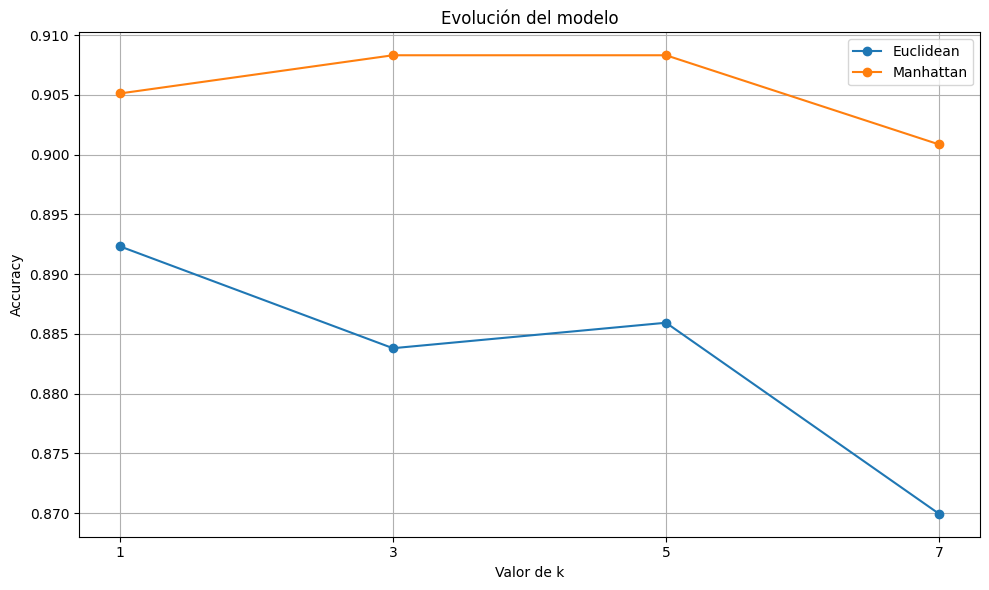

In [20]:
df_resultados = pd.DataFrame(resultados, columns=["k", "Métrica", "Accuracy"])

df_euclidean = df_resultados[df_resultados["Métrica"] == "euclidean"]
df_manhattan = df_resultados[df_resultados["Métrica"] == "manhattan"]

plt.figure(figsize=(10, 6))
plt.plot(df_euclidean["k"], df_euclidean["Accuracy"], marker='o', label="Euclidean")
plt.plot(df_manhattan["k"], df_manhattan["Accuracy"], marker='o', label="Manhattan")

plt.title("Evolución del modelo")
plt.xlabel("Valor de k")
plt.ylabel("Accuracy")
plt.xticks(valores_k)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

**Enunciado:** Utiliza el clasificador para saber que ocurre con los asteroides de un dataset que se llame *“nasa_clasificar.csv”* que obtendremos del dataset proporcionado.

**Solución**

Lo primero que haremos será generar nuestro dataset de pruebas. Para ello, cogeremos 50 registros aleatorios del dataset de entrenamiento y generaremos un nuevo csv, que sea nasa_clasificar.csv.

In [21]:
subset_clasificar = df_nasa.sample(n=50, random_state=42)

subset_clasificar.to_csv("./data/nasa_clasificar.csv", index=False)

Una vez tenemos el dataset de pruebas, tendremos que realizar el mismo preprocesamineto para poder utilizar nuestro clasificador correctamente.

In [22]:
df_clasificacion = pd.read_csv("./data/nasa_clasificar.csv")

df_clasificacion["Close Approach Date"] = pd.to_datetime(df_clasificacion["Close Approach Date"], errors='coerce').astype('int64') / 10**9
df_clasificacion["Orbit Determination Date"] = pd.to_datetime(df_clasificacion["Orbit Determination Date"], errors='coerce').astype('int64') / 10**9
df_clasificacion["Epoch Date Close Approach"] = pd.to_numeric(df_clasificacion["Epoch Date Close Approach"], errors='coerce')
df_clasificacion["Perihelion Time"] = pd.to_numeric(df_clasificacion["Perihelion Time"], errors='coerce')

x_clasificacion = df_clasificacion.drop(columns=["Hazardous"])
x_clasificacion_normalizado = scaler.transform(x_clasificacion)

y_pred_clasificacion = knn.predict(x_clasificacion_normalizado)
y_true_clasificacion = df_clasificacion["Hazardous"]

accuracy = accuracy_score(y_true_clasificacion, y_pred_clasificacion)

df_clasificacion["Predicted Hazardous"] = y_pred_clasificacion
df_clasificacion["Correct Classification"] = df_clasificacion["Predicted Hazardous"] == df_clasificacion["Hazardous"]

print(df_clasificacion[["Name", "Hazardous", "Predicted Hazardous", "Correct Classification"]])
print(f"Accuracy de las pruebas: {accuracy}")


       Name  Hazardous  Predicted Hazardous  Correct Classification
0   2490581       True                 True                    True
1   3608620      False                False                    True
2   3028805       True                False                   False
3   3690058      False                False                    True
4   3623679      False                False                    True
5   2392704      False                False                    True
6   3744851      False                False                    True
7   2010165      False                False                    True
8   3388354      False                False                    True
9   3736239      False                False                    True
10  3548663      False                False                    True
11  3693515      False                False                    True
12  3601673      False                False                    True
13  2237805      False                False     